# Use of the module

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from KGsolver import RiccatiModel
import KGsolver as kg
from KGsolver.plotting import plot_potential

# 
import pandas as pd

## Exponential Hyperbolic Tangent potential (alpha potential)

In [55]:
V, VL, VR, label = kg.expTanhPotential(a=-10,b=1, c= 1)
model1 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=8000)

E_mod1,R_mod1,T_mod1 = model1.compute_RT_spectrum(E_min=-30, E_max=2, nE=600)


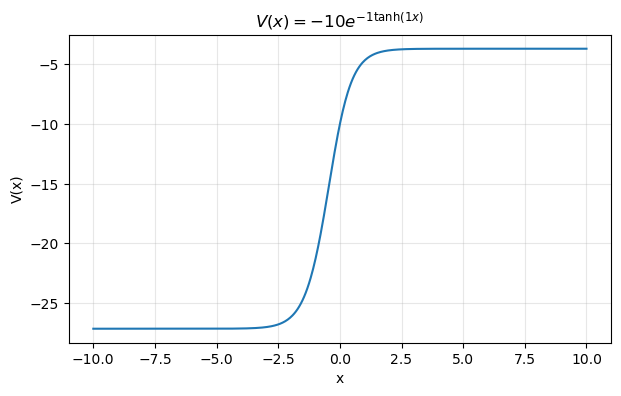

In [56]:
# potential
plot_potential(model1)

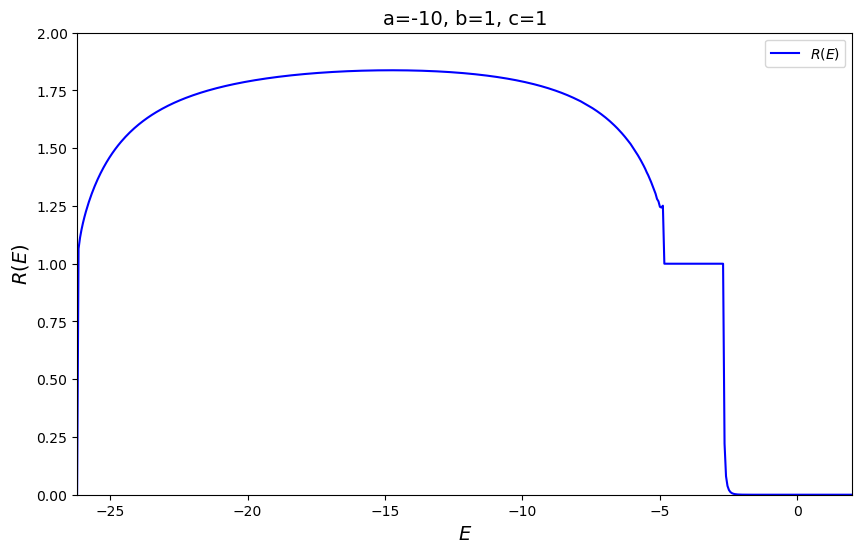

In [57]:
plt.figure(figsize=(10,6))
plt.plot(E_mod1, R_mod1, color="b",label=r"$R(E)$")
#plt.plot(E_mod1, T_mod1, color="r",label=r"$T(E)$")
plt.legend()
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$R(E)$", fontsize=14)
plt.title("a=-10, b=1, c=1", fontsize=14)
plt.xlim(-26.2,2)
plt.ylim(0,2)
plt.savefig("R(E).png", dpi=300)
plt.show()

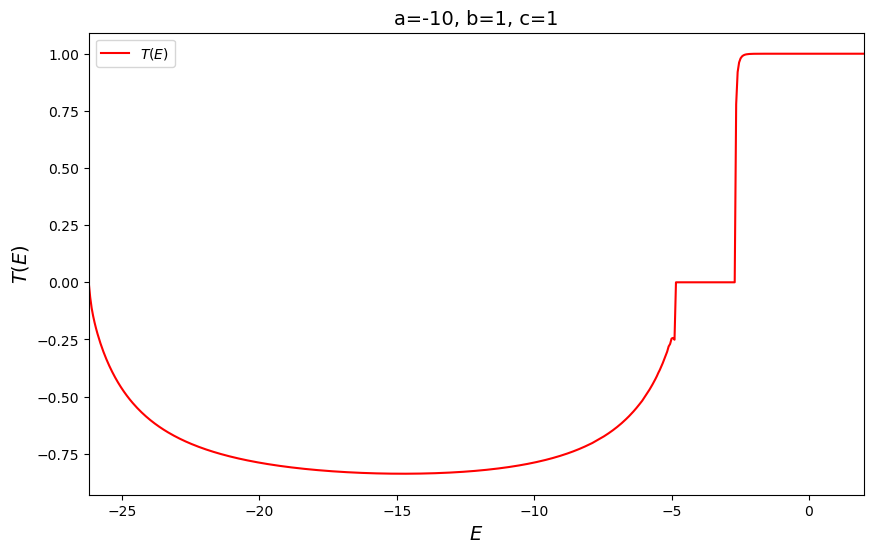

In [58]:
plt.figure(figsize=(10,6))
#plt.plot(E_mod1, R_mod1, color="b",label=r"$R(E)$")
plt.plot(E_mod1, T_mod1, color="r",label=r"$T(E)$")
plt.legend()
plt.title("a=-10, b=1, c=1", fontsize=14)
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$T(E)$", fontsize=14)
plt.xlim(-26.2,2)
plt.savefig("T(E).png", dpi=300)
plt.show()

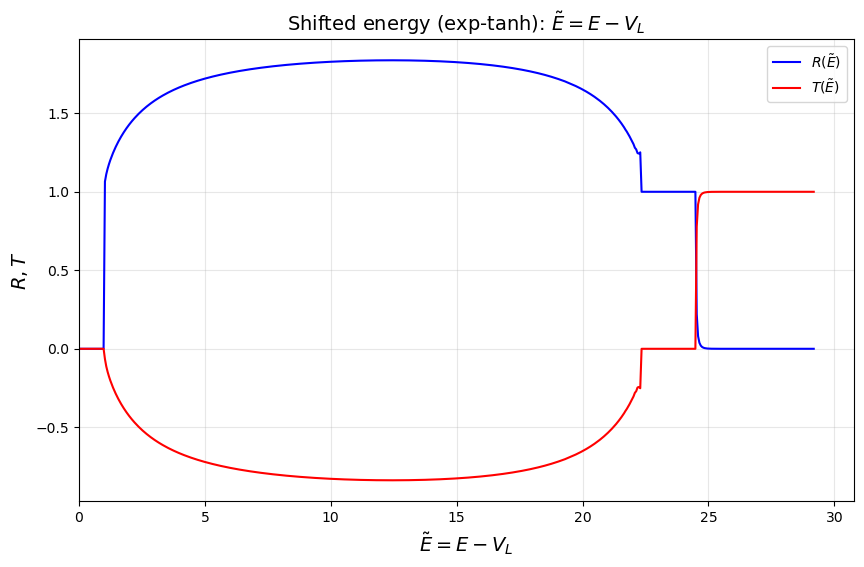

exp-tanh: V_L=-27.1828, V_R=-3.67879, m=1
Raw superradiant window (step approx): (V_L+m, V_R-m)=(-26.1828, -4.67879)
Shifted window in Etilde: (m, (V_R-V_L)-m)=(1, 22.504)


In [59]:
# Shifted-energy plot: E_tilde = E - V_L (left asymptotic plateau)
Etilde_mod1 = E_mod1 - model1.VL

plt.figure(figsize=(10,6))
plt.plot(Etilde_mod1, R_mod1, color="b", label=r"$R(\tilde E)$")
plt.plot(Etilde_mod1, T_mod1, color="r", label=r"$T(\tilde E)$")
plt.xlabel(r"$\tilde E = E - V_L$", fontsize=14)
plt.ylabel(r"$R, T$", fontsize=14)
plt.title(r"Shifted energy (exp-tanh): $\tilde E = E - V_L$", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(left=0)
plt.show()

print(f"exp-tanh: V_L={model1.VL:.6g}, V_R={model1.VR:.6g}, m={model1.m:.6g}")
print(f"Raw superradiant window (step approx): (V_L+m, V_R-m)=({model1.VL+model1.m:.6g}, {model1.VR-model1.m:.6g})")
print(f"Shifted window in Etilde: (m, (V_R-V_L)-m)=({model1.m:.6g}, {(model1.VR-model1.VL)-model1.m:.6g})")


## Hyperbolic Tangent Potential

### Figure 1

In [2]:
V, VL, VR, label = kg.TanhPotential(a=5,b=1)
model2 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=6000)

E_mod2,R_mod2,T_mod2 = model2.compute_RT_spectrum(E_min=0.1, E_max=10, nE=100)

In [3]:
# analytic results for tanh potential
data_T1  = np.array(pd.read_csv("/home/angeldavid/Desktop/9th-semester/RQM/RelativisticQuantumMechanics/Analytic-data/Tanh/T1_tanh.dat",delimiter= "\t"))
data_R1 = np.array(pd.read_csv("/home/angeldavid/Desktop/9th-semester/RQM/RelativisticQuantumMechanics/Analytic-data/Tanh/R1_tanh.dat",delimiter= "\t"))
data_T  = np.array(pd.read_csv("/home/angeldavid/Desktop/9th-semester/RQM/RelativisticQuantumMechanics/Analytic-data/Tanh/T_tanh.dat",delimiter= "\t"))
data_R = np.array(pd.read_csv("/home/angeldavid/Desktop/9th-semester/RQM/RelativisticQuantumMechanics/Analytic-data/Tanh/R_tanh.dat",delimiter= "\t"))

In [4]:
fullT = np.concatenate((data_T1[:,1], data_T[:,1]))
fullR = np.concatenate((data_R1[:,1], data_R[:,1]))
fullET = np.concatenate((data_T1[:,0], data_T[:,0]))
fullER = np.concatenate((data_R1[:,0], data_R[:,0]))

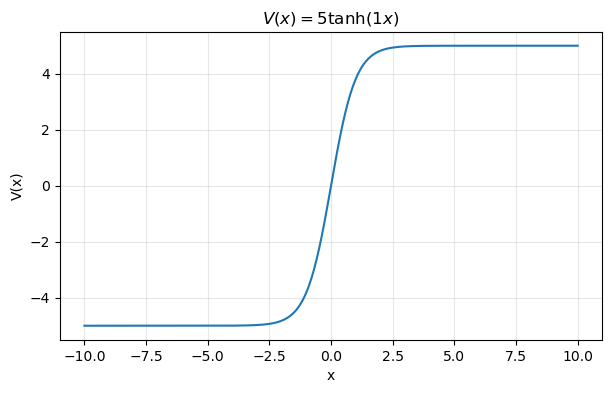

In [5]:
plot_potential(model2)

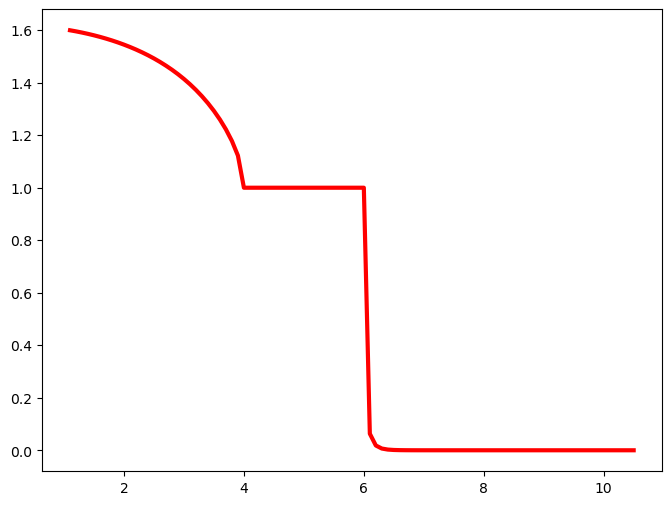

In [117]:
plt.figure(figsize=(8,6))
plt.plot(fullER, fullR, color="r", linestyle="-", linewidth=3, label=r"Analytic $R(E)$")
#plt.plot(E_mod2, R_mod2, color="b", linestyle="--", label=r"$R(E)$")
plt.show()

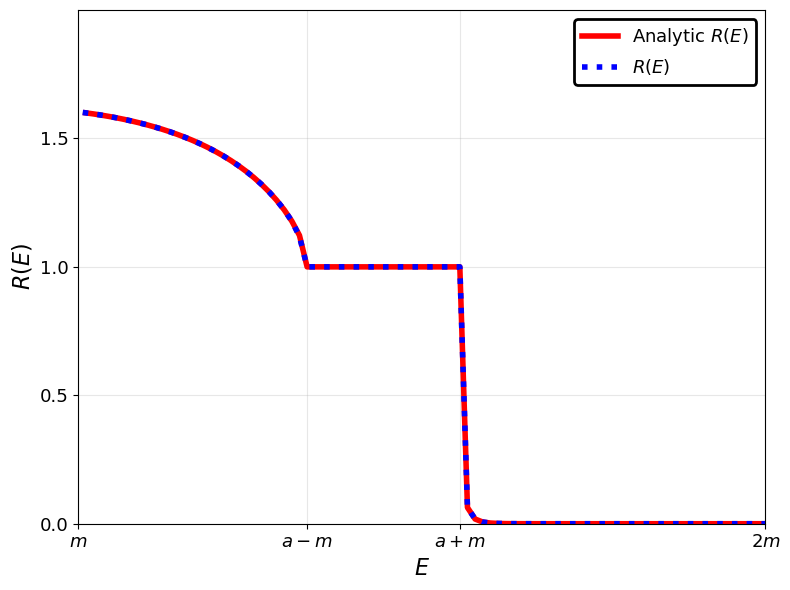

In [6]:
m = 1

plt.figure(figsize=(8, 6))

plt.plot(fullER, fullR, color="r", linestyle="-", linewidth=4,label=r"Analytic $R(E)$")
plt.plot(E_mod2, R_mod2, color="b", linestyle="dotted",linewidth=4, label=r"$R(E)$")


plt.xlabel(r"$E$", fontsize=16)
plt.ylabel(r"$R(E)$", fontsize=16)
#plt.title(r"$a=5,\; b=2$", fontsize=14)

plt.xlim(m, 4*m)
plt.ylim(0, 2)

# Custom ticks in units of m
a=5
plt.xticks(
    [m, a-m, a+m, 2*a],
    [r"$m$", r"$a-m$", r"$a+m$", r"$2m$"],
    fontsize=13
)
#xtick_labels = [r"$m$", r"$1.25m$", r"$1.5m$", r"$1.75m$", r"$2m$"]



plt.tick_params(axis='y', labelsize=13)
plt.yticks(np.arange(0, 2, 0.5))
plt.grid(True, alpha=0.3)

leg = plt.legend(
    fontsize=13,
    loc="best",
    frameon=True,
    fancybox=True,
    framealpha=1,
    edgecolor="black",
    facecolor="white"
)
leg.get_frame().set_linewidth(2)

plt.tight_layout()
plt.savefig("R(E)_tanh.png", dpi=300)
plt.show()

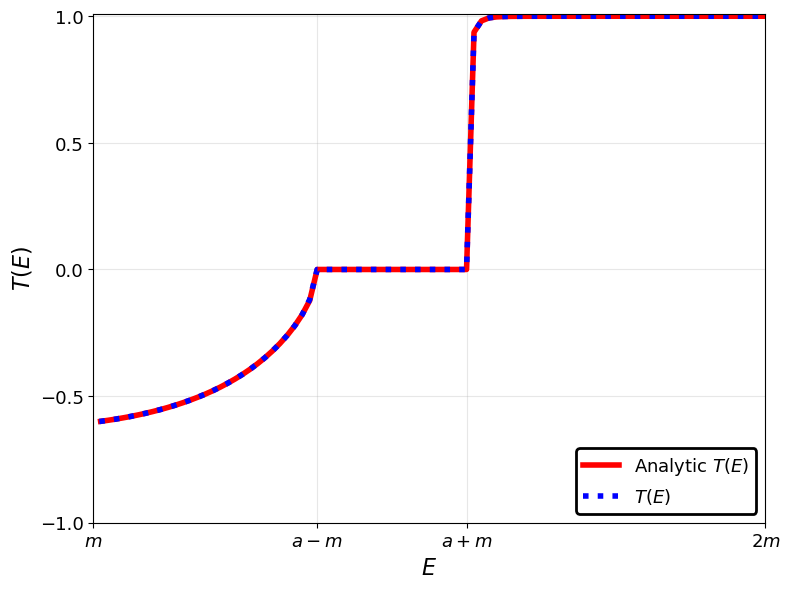

In [7]:
m = 1

plt.figure(figsize=(8, 6))

plt.plot(fullET, fullT, color="r", linestyle="-", linewidth=4,
         label=r"Analytic $T(E)$")
plt.plot(E_mod2, T_mod2, color="b", linestyle="dotted", linewidth=4, label=r"$T(E)$")


plt.xlabel(r"$E$", fontsize=16)
plt.ylabel(r"$T(E)$", fontsize=16)
#plt.title(r"$a=5,\; b=2$", fontsize=14)

plt.xlim(m, 4*m)
plt.ylim(-1, 1.01)

# Custom ticks in units of m
a=5
plt.xticks(
    [m, a-m, a+m, 2*a],
    [r"$m$", r"$a-m$", r"$a+m$", r"$2m$"],
    fontsize=13
)
#xtick_labels = [r"$m$", r"$1.25m$", r"$1.5m$", r"$1.75m$", r"$2m$"]



plt.tick_params(axis='y', labelsize=13)
plt.yticks(np.arange(-1, 1.01, 0.5))
plt.grid(True, alpha=0.3)

leg = plt.legend(
    fontsize=13,
    loc=4,
    frameon=True,
    fancybox=True,
    framealpha=1,
    edgecolor="black",
    facecolor="white"
)
leg.get_frame().set_linewidth(2)

plt.tight_layout()
plt.savefig("T(E)_tanh.png", dpi=300)
plt.show()

We shif the energy from the left

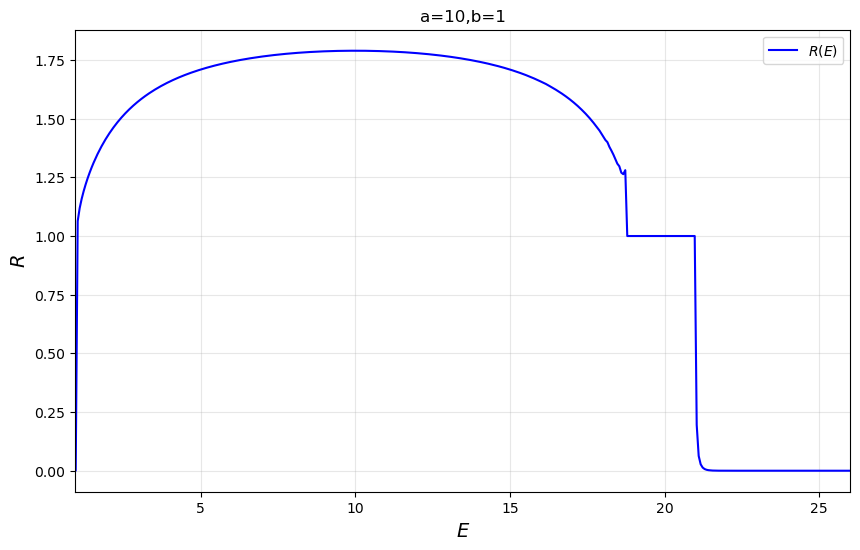

tanh: V_L=-25, V_R=-5, m=1
Raw superradiant window (step approx): (V_L+m, V_R-m)=(-24, -6)
Shifted window in Etilde: (m, (V_R-V_L)-m)=(1, 19)


In [44]:
# Shifted-energy plot: E_tilde = E - V_L (left asymptotic plateau)
Etilde_mod2 = E_mod2 - model2.VL

plt.figure(figsize=(10,6))
plt.plot(Etilde_mod2, R_mod2, color="b", label=r"$R(E)$")
#plt.plot(Etilde_mod2, T_mod2, color="r", label=r"$T(\tilde E)$")
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$R$", fontsize=14)
#plt.title(r"Shifted energy (tanh): $\tilde E = E - V_L$", fontsize=14)
plt.title("a=10,b=1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0.95,26)
plt.savefig("tanh-R.png")
plt.show()

print(f"tanh: V_L={model2.VL:.6g}, V_R={model2.VR:.6g}, m={model2.m:.6g}")
print(f"Raw superradiant window (step approx): (V_L+m, V_R-m)=({model2.VL+model2.m:.6g}, {model2.VR-model2.m:.6g})")
print(f"Shifted window in Etilde: (m, (V_R-V_L)-m)=({model2.m:.6g}, {(model2.VR-model2.VL)-model2.m:.6g})")


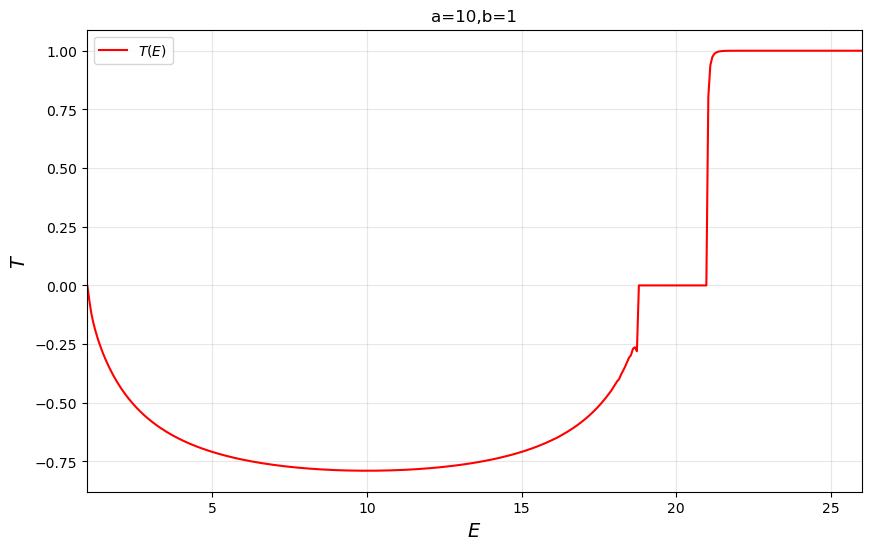

In [45]:

plt.figure(figsize=(10,6))
#plt.plot(Etilde_mod2, R_mod2, color="b", label=r"$R(E)$")
plt.plot(Etilde_mod2, T_mod2, color="r", label=r"$T(E)$")
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$T$", fontsize=14)
#plt.title(r"Shifted energy (tanh): $\tilde E = E - V_L$", fontsize=14)
plt.title("a=10,b=1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0.95,26)
plt.savefig("tanh-T.png")
plt.show()


### Figure 2

In [13]:
V, VL, VR, label = kg.TanhPotential(a=5,b=50)
model2 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=6000)

E_mod2,R_mod2,T_mod2 = model2.compute_RT_spectrum(E_min=0.1, E_max=10, nE=200)

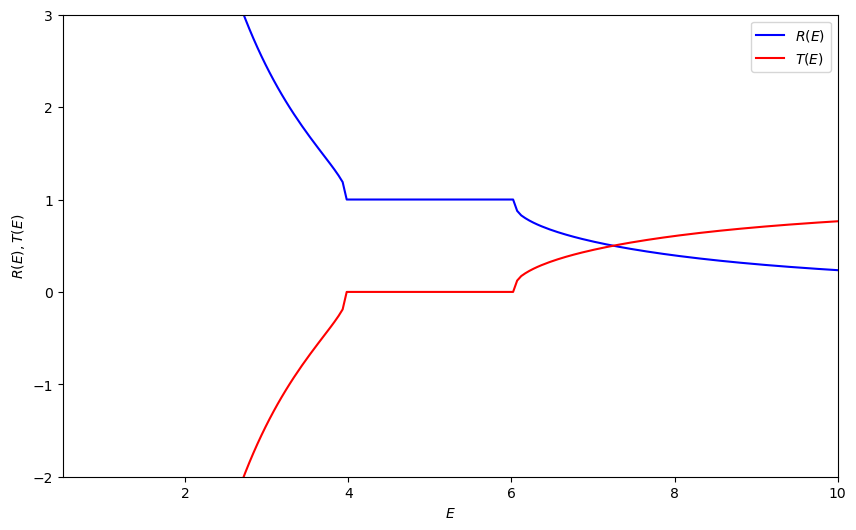

In [18]:
plt.figure(figsize=(10,6))
plt.plot(E_mod2, R_mod2, color="b",label=r"$R(E)$")
plt.plot(E_mod2, T_mod2, color="r",label=r"$T(E)$")
plt.xlabel(r"$E$")
plt.ylabel(r"$R(E), T(E)$")
plt.ylim(-2,3)
plt.xlim(0.5,10)
plt.legend()
plt.show()

### Woods-Saxon Potential 

In [ ]:
V, VL, VR, label = kg.woodsSaxonPotential(V0=4,a=10,b=2)
model3 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=6000)
    
E_mod3,R_mod3,T_mod3 = model3.compute_RT_spectrum(E_min=0.1, E_max=10, nE=200)

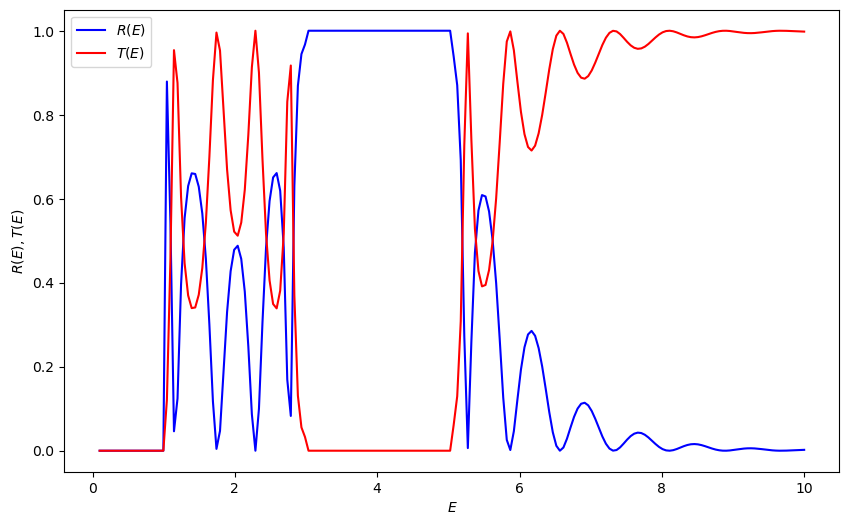

In [44]:
plt.figure(figsize=(10,6))
plt.plot(E_mod3, R_mod3, color="b",label=r"$R(E)$")
plt.plot(E_mod3, T_mod3, color="r",label=r"$T(E)$")
plt.xlabel(r"$E$")
plt.ylabel(r"$R(E), T(E)$")
plt.legend()
plt.show()

**Let's limit the x range for V0-m, where m is the mass (m=1)**

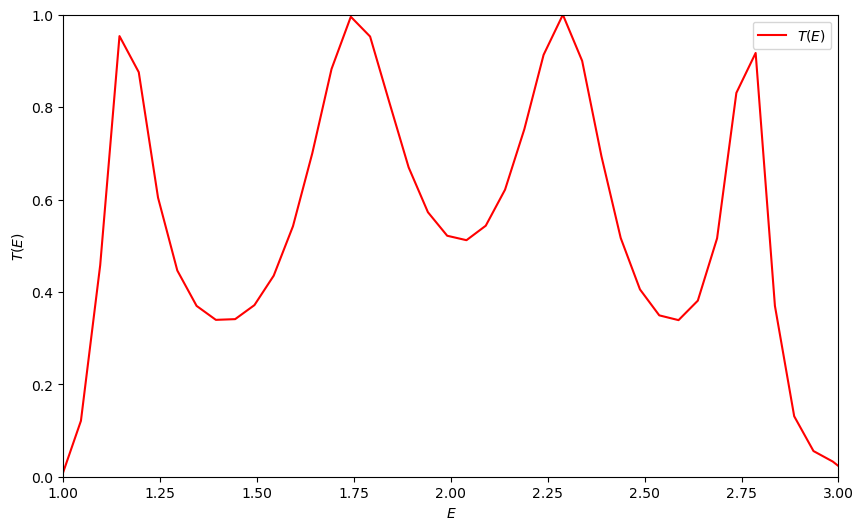

In [ ]:
plt.figure(figsize=(10,6))
#plt.plot(E_mod3, R_mod3, color="b",label=r"$R(E)$")
plt.plot(E_mod3, T_mod3, color="r",label=r"$T(E)$")
plt.xlabel(r"$E$")
#plt.ylabel(r"$R(E), T(E)$")
plt.ylabel(r"$T(E)$")
plt.xlim(1,3)
plt.ylim(0,1)
plt.legend()
plt.show()

## Cups Potential

In [53]:
V, VL, VR, label = kg.cupsPotential(V0=4,a=1)
model4 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=6000)
    
E_mod4,R_mod4,T_mod4 = model4.compute_RT_spectrum(E_min=0.1, E_max=10, nE=500)

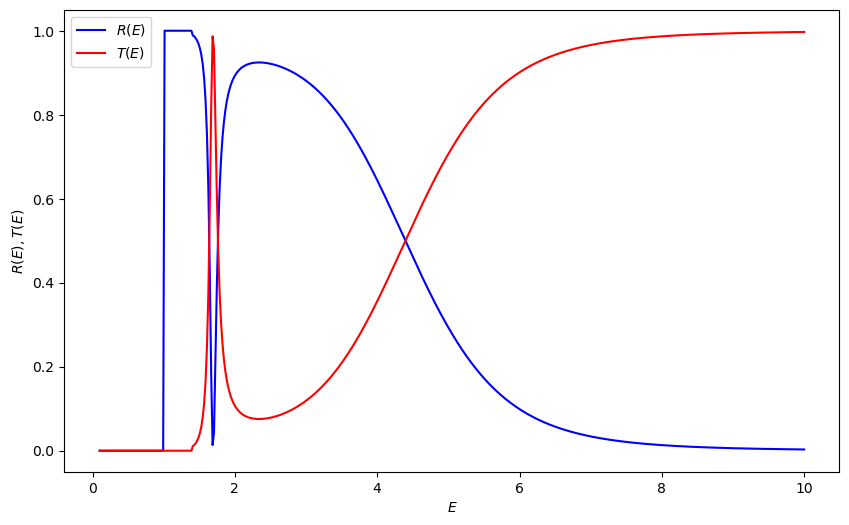

In [54]:
plt.figure(figsize=(10,6))
plt.plot(E_mod4, R_mod4, color="b",label=r"$R(E)$")
plt.plot(E_mod4, T_mod4, color="r",label=r"$T(E)$")
plt.xlabel(r"$E$")
plt.ylabel(r"$R(E), T(E)$")
plt.legend()
plt.show()